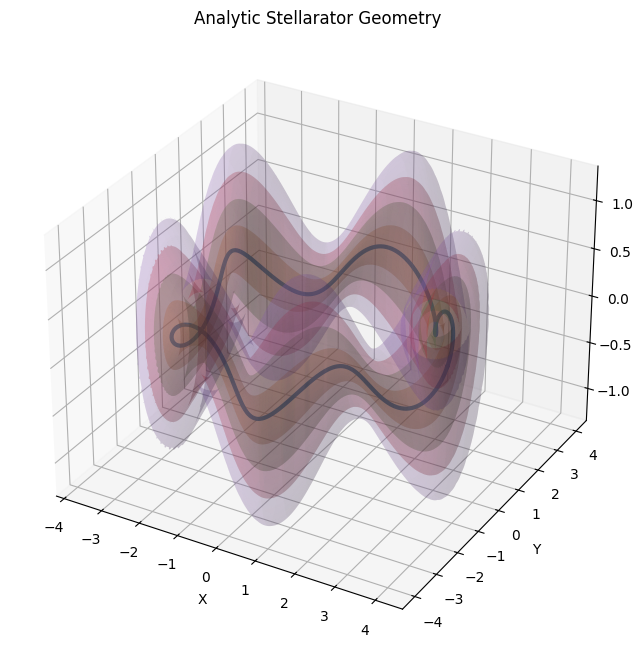

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from magtrace.fields.analytic_stellarator import AnalyticStellarator


stellarator = AnalyticStellarator(
    R0=3.0,
    axis_amplitude=0.3,
    Nfp=5,
    iota=0.7
)


fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(
    111,
    projection="3d"
)


# plot magnetic axis

phi = np.linspace(
    0,
    2*np.pi,
    1000
)


R,Z = stellarator.magnetic_axis(phi)

x,y,z = stellarator.cylindrical_to_cartesian(
    R,
    phi,
    Z
)


ax.plot(
    x,
    y,
    z,
    linewidth=3,
    label="Magnetic Axis"
)


# plot several flux surfaces

for r in [0.2,0.4,0.6,0.8]:

    theta = np.linspace(
        0,
        2*np.pi,
        200
    )

    phi_grid, theta_grid = np.meshgrid(
        phi,
        theta
    )


    R,Z = stellarator.flux_surface(
        r,
        theta_grid,
        phi_grid
    )


    x,y,z = stellarator.cylindrical_to_cartesian(
        R,
        phi_grid,
        Z
    )


    ax.plot_surface(
        x,
        y,
        z,
        alpha=0.15
    )


ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

ax.set_title(
    "Analytic Stellarator Geometry"
)

plt.savefig("figures/stellarator_geometry.png")
plt.show()

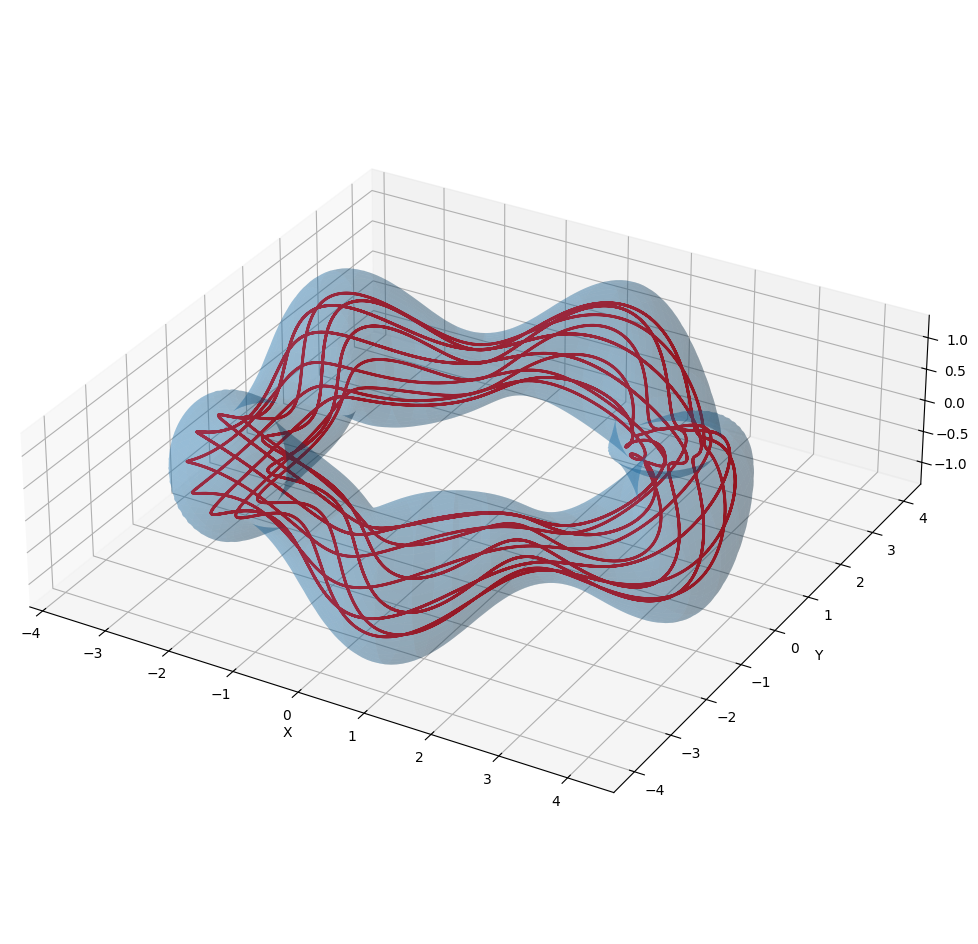

In [9]:
fig = plt.figure(figsize=(18,12))
ax = fig.add_subplot(111, projection="3d")

ax.set_box_aspect([2,2,0.6])

# -------------------------
# Plasma surface
# -------------------------

theta = np.linspace(0, 2*np.pi, 100)
phi = np.linspace(0, 2*np.pi, 300)

phi_grid, theta_grid = np.meshgrid(phi, theta)

R, Z = stellarator.flux_surface(
    r=0.8,
    theta=theta_grid,
    phi=phi_grid
)

x, y, z = stellarator.cylindrical_to_cartesian(R, phi_grid, Z)

ax.plot_surface(
    x,
    y,
    z,
    alpha=0.25,
    linewidth=0
)

# -------------------------
# Field line
# -------------------------

x, y, z = stellarator.trace_field_line(
    r=0.55,
    turns=25
)

ax.plot(
    x,
    y,
    z,
    color="red",
    linewidth=2
)

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

plt.savefig("figures/fluxsurface_with_fieldlines.png")
plt.show()